In [1]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from lammps import lammps

sys.path.insert(0, '..')
from src import *

# Set number of OpenMP threads
os.environ['OMP_NUM_THREADS'] = '10'

In [2]:
rho = 1.058  # Density (reduced units)
L = 10  # Box length (in lattice units)

epsilon = 1.0  # LJ energy scale
sigma = 1.0    # LJ length scale

offset = 0.05  # to avoid creating atoms on simbox face

T = 1.0   # temperature (reduced units)
time_step = 0.0005  # Time step (reduced units)
thermo_tau = 100 * time_step  # Thermostat damping parameter
baro_tau = 1000 * time_step

equil_temp_steps = 10_000 
# equil_press_steps = 10_000
prod_steps = 1000

save_every = 1
sample_interval = 1000

In [3]:
savedir = f"../data/test/test_T{T}"
os.makedirs(savedir, exist_ok=True)
print(savedir)

../data/test/test_T1.0


In [4]:
lmp = lammps(cmdargs=['-log', os.path.join(savedir,'sim.log'), '-sf', 'omp', 
                      "-screen", "none", "-nocite"])

input_script = f"""
units lj
dimension 3
boundary p p p
atom_style atomic

lattice fcc {rho} origin {offset} {offset} {offset}
region simbox block 0 {L} 0 {L} 0 {L} units lattice
create_box 1 simbox
create_atoms 1 box
mass 1 1.0
velocity all create {T} 94673 mom yes

pair_style lj/smooth 2.5 3.5
pair_coeff 1 1 1.0 1.0
pair_modify shift yes

compute temp all temp

variable time equal time
variable etot equal etotal
variable vol equal vol
variable dens equal density

compute press all pressure thermo_temp
compute press_pot all pressure NULL virial
compute born_matrix all born/matrix numdiff 1.0e-6 press_pot
compute born_matrix_nl all born/matrix/nonlinear 1.0e-6 press_pot born_matrix

# Screen and log output
thermo 1000
thermo_style custom step temp press density vol etotal
thermo_modify flush yes

# Timestep (default 0.005 for lennard-jones)
timestep {time_step}


# === EQUILIBRATION RUN =========================
fix nvt_eq all nvt temp {T} {T} {thermo_tau}
run {equil_temp_steps}
unfix nvt_eq


# === PRODUCTION RUN ==============================

# Keep constant energy
fix nve_prod all nve

# Run production
run {prod_steps}
"""

lmp.commands_string(input_script)
#lmp.command(f'write_data "{savedir}/snapshot_ref.dump" nocoeff')

In [5]:
lmp.get_natoms()

4000

In [6]:
def cell_is_undeformed(lmp):
    cm = get_cell_matrix(lmp)
    return np.all(cm == cm[0,0] * np.eye(3))

cell_matrix = get_cell_matrix(lmp)

In [7]:
def probe_deformations_general(eps):
    map_ij = voigt_to_tensor_index_map()
    deforms = np.zeros((9, 3, 3))
    for k, (i, j) in enumerate(map_ij):
        deforms[k, i, j] = eps
    return deforms, map_ij

In [8]:
I = np.eye(3)

# Nonlinear Born

In [9]:
V = lmp.numpy.extract_variable("vol")
born_nl_raw = lmp.numpy.extract_compute("born_matrix_nl", 0, 1) / V
born_nl = born_nl_raw.reshape(21, 6).T
born_nl = lammps_array_to_matrix(born_nl)
NB_lammps = voigt_to_tensor(born_nl, 3)

In [10]:
def get_pk2_pot(lmp, cell_matrix_ref, F, eps=1e-7):
    set_cell_matrix(lmp, F@cell_matrix_ref, remap=True, convert=True)
    F_inv = np.linalg.inv(F)
    sigma = -lammps_array_to_matrix(lmp.numpy.extract_compute("press_pot", 0, 1))
    return np.linalg.det(F) * F_inv @ sigma @ F_inv.T

def compute_F_deform(E):
    return np.linalg.cholesky(I + 2*E, upper=True)

def compute_born_nonlin_pk2_der(lmp, cell_matrix=None, eps=1e-6, undeform=True):
    E_deforms, map_ij = probe_deformations_sym(eps)
    
    lmp.command("change_box all triclinic")
    h0 = get_cell_matrix(lmp) if cell_matrix is None else cell_matrix
    NB = np.zeros((3,)*6)
    
    for (k,l), dE1 in zip(map_ij, E_deforms):
        for (m,n), dE2 in zip(map_ij, E_deforms):
            S11 = get_pk2_pot(lmp, h0, compute_F_deform(- dE1 - dE2))
            S12 = get_pk2_pot(lmp, h0, compute_F_deform(- dE1 + dE2))
            S21 = get_pk2_pot(lmp, h0, compute_F_deform(+ dE1 - dE2))
            S22 = get_pk2_pot(lmp, h0, compute_F_deform(+ dE1 + dE2))
            NB[:,:,k,l,m,n] = (S22 + S11 - S12 - S21) / (4 * eps**2)
            if m != n:
                NB[:, :, k, l, n, m] = NB[:, :, k, l, m, n]
        if k != l:
            NB[:, :, l, k] = NB[:, :, k, l]
    for (i,j) in map_ij[3:]:
        NB[j,i] = NB[i,j]
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)

    return NB

In [11]:
eps_arr = np.logspace(-1, -8, 15)
diff_arr = np.zeros_like(eps_arr)
for k, eps in enumerate(eps_arr):
    NB = compute_born_nonlin_pk2_der(lmp, cell_matrix=cell_matrix, eps=eps)
    diff_arr[k] = np.linalg.norm(NB_lammps - NB) / np.linalg.norm(NB)

cell_is_undeformed(lmp)

np.True_

In [12]:
eps_arr = np.logspace(-1, -8, 15)
diff_arr = np.zeros_like(eps_arr)
NB_ref = compute_born_nonlin_pk2_der(lmp, cell_matrix=cell_matrix, eps=1e-5)
for k, eps in enumerate(eps_arr):
    NB = compute_born_nonlin_pk2_der(lmp, cell_matrix=cell_matrix, eps=eps)
    diff_arr[k] = np.linalg.norm(NB_ref - NB) / np.linalg.norm(NB)

cell_is_undeformed(lmp)

np.True_

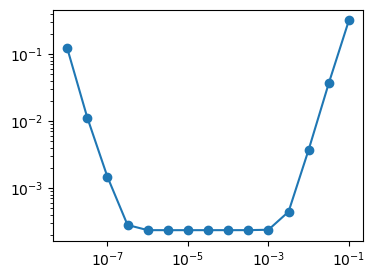

In [12]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, 'o-')
plt.xscale("log")
plt.yscale("log")

In [13]:
diff_arr.min()

np.float64(0.00023531764859967993)

In [14]:
NB = compute_born_nonlin_pk2_der(lmp, cell_matrix=cell_matrix, eps=1e-5)

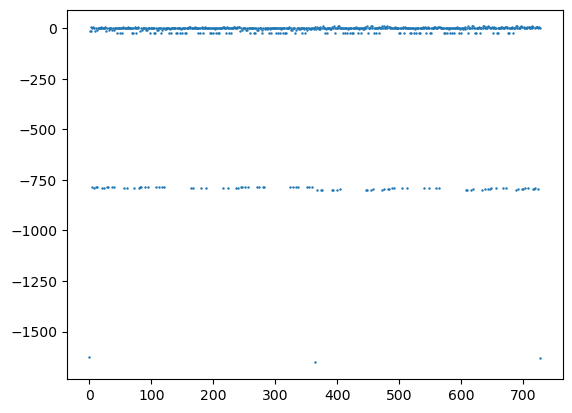

In [15]:
plt.plot(NB.flatten(), '.', ms=1.5)

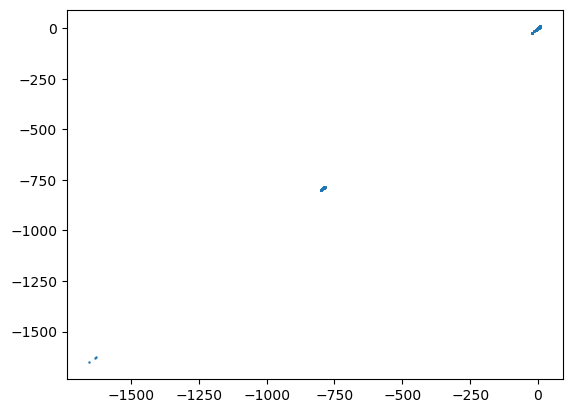

In [16]:
plt.plot(NB_lammps.flatten(), NB.flatten(), '.', ms=1.5)

# Born term

In [17]:
def major_symmetry(tens, ind=None, norm_ord=2):
    tens_t = np.swapaxes(np.swapaxes(tens, -1, -3), -2, -4)
    diff = tens - tens_t
    if ind is None:
        return np.linalg.norm(diff.flatten(), ord=norm_ord)
    return diff[*ind]

In [18]:
get_cell_matrix(lmp)

array([[15.578469,  0.      ,  0.      ],
       [ 0.      , 15.578469,  0.      ],
       [ 0.      ,  0.      , 15.578469]])

In [19]:
cell_matrix

array([[15.578469,  0.      ,  0.      ],
       [ 0.      , 15.578469,  0.      ],
       [ 0.      ,  0.      , 15.578469]])

## as stress derivative

### at zero strain

In [20]:
lmp.command("change_box all triclinic")
set_cell_matrix(lmp, cell_matrix, remap=True)
cell_is_undeformed(lmp)

np.True_

In [21]:
born_raw = lmp.numpy.extract_compute("born_matrix", 0, 1) / lmp.numpy.extract_variable("vol")
born_voigt = lammps_array_to_matrix(born_raw)
CB_lammps = voigt_to_tensor(born_voigt)
sigma_lammps = -lammps_array_to_matrix(lmp.numpy.extract_compute("press_pot", 0, 1).copy())

cell_is_undeformed(lmp)

np.True_

In [22]:
def get_pk2_pot(lmp, cell_matrix_ref, F):
    set_cell_matrix(lmp, F @ cell_matrix_ref, remap=True)
    sigma = -lammps_array_to_matrix(lmp.numpy.extract_compute("press_pot", 0, 1).copy())
    F_inv = np.linalg.inv(F)
    return np.linalg.det(F) * F_inv @ sigma @ F_inv.T

def compute_born_stress_der(lmp, cell_matrix_ref=None, eps=1e-7, undeform=True):
    deforms, map_ij = probe_deformations(eps)
    
    lmp.command("change_box all triclinic")
    h0 = get_cell_matrix(lmp) if (cell_matrix_ref is None) else cell_matrix_ref
    CB = np.zeros((3,)*4)
    
    for (k,l), deform in zip(map_ij, deforms):
        S1 = get_pk2_pot(lmp, h0, np.eye(3)-deform)
        S2 = get_pk2_pot(lmp, h0, np.eye(3)+deform)
        CB[..., k, l] = (S2 - S1)/(2*eps)
        if k != l:
            CB[..., l, k] = CB[..., k, l]
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)

    return CB

In [23]:
eps_arr = np.logspace(-3, -10, 29)
diff_arr = np.zeros_like(eps_arr)
for k, eps in enumerate(eps_arr):
    CB = compute_born_stress_der(lmp, cell_matrix_ref=cell_matrix, eps=eps)
    diff_arr[k] = np.linalg.norm(CB_lammps - CB) / np.linalg.norm(CB_lammps)

cell_is_undeformed(lmp)

np.True_

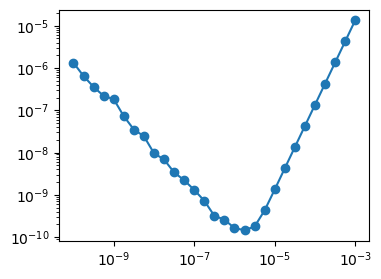

In [24]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, 'o-')
plt.xscale("log")
plt.yscale("log")

In [25]:
diff_arr

array([1.35167398e-05, 4.27412787e-06, 1.35159734e-06, 4.27445598e-07,
       1.35157609e-07, 4.27263637e-08, 1.34995125e-08, 4.25624446e-09,
       1.33847114e-09, 4.31932661e-10, 1.78437092e-10, 1.45914490e-10,
       1.63059452e-10, 2.59574418e-10, 3.18738164e-10, 7.24517733e-10,
       1.30618702e-09, 2.21917353e-09, 3.39604985e-09, 6.85230421e-09,
       9.67006210e-09, 2.43077747e-08, 3.50455311e-08, 7.24850015e-08,
       1.83161840e-07, 2.18731102e-07, 3.56842782e-07, 6.46359223e-07,
       1.33107964e-06])

In [26]:
CB = compute_born_stress_der(lmp, eps=1e-7)
major_symmetry(CB)

np.float64(4.641087474144845e-07)

In [27]:
cell_is_undeformed(lmp)

np.True_

In [28]:
def get_cauchy_pot(lmp, cell_matrix):
    set_cell_matrix(lmp, cell_matrix, remap=True)
    return -lammps_array_to_matrix(lmp.numpy.extract_compute("press_pot", 0, 1))

def compute_born_stress_der2(lmp, cell_matrix_ref=None, eps=1e-7, undeform=True):
    deforms, map_ij = probe_deformations(eps)
    
    h0 = get_cell_matrix(lmp) if (cell_matrix_ref is None) else cell_matrix_ref
    sigma = get_cauchy_pot(lmp, h0)
    CB = np.zeros((3,)*4)

    for (k,l), deform in zip(map_ij, deforms):
        F1 = np.eye(3)-deform
        F2 = np.eye(3)+deform
        S1 = get_cauchy_pot(lmp, F1@h0) #* np.linalg.det(F1)
        S2 = get_cauchy_pot(lmp, F2@h0) #* np.linalg.det(F2)
        CB[:, :, k, l] = (S2 - S1)/(2*eps) + sigma*(k==l)
        for (i,j) in map_ij:
            CB[i, j, k, l] -= (i==k) * sigma[j,l] + (j==k) * sigma[i,l]
            if i != j:
                CB[j, i, k, l] = CB[i, j, k, l]
        if k != l:
            CB[:, :, l, k] = CB[:, :, k, l]
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)

    return CB

In [29]:
eps_arr = np.logspace(-1, -12, 23)
diff_arr = np.zeros_like(eps_arr)
for k, eps in enumerate(eps_arr):
    CB = compute_born_stress_der2(lmp, cell_matrix_ref=cell_matrix, eps=eps, undeform=True)
    diff_arr[k] = np.linalg.norm(CB_lammps - CB) / np.linalg.norm(CB_lammps)

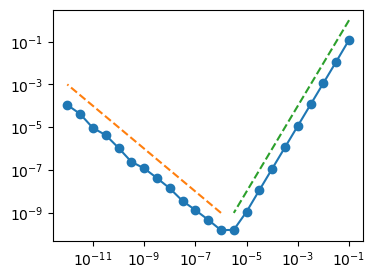

In [30]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, 'o-')
i1 = 13
i2 = 10
plt.plot(eps_arr[-i1:], eps_arr[-i1:]**(-1) / 10**15, '--')
plt.plot(eps_arr[:i2], eps_arr[:i2]**2 * 10**2, '--')
plt.xscale("log")
plt.yscale("log")

In [31]:
cell_is_undeformed(lmp)

np.True_

In [32]:
set_cell_matrix(lmp, cell_matrix)

In [33]:
def get_cauchy_pot(lmp, cell_matrix):
    set_cell_matrix(lmp, cell_matrix, remap=True, convert=True)
    return -lammps_array_to_matrix(lmp.numpy.extract_compute("press_pot", 0, 1))

def compute_F_from_e(e):
    return np.linalg.inv(np.linalg.cholesky(I - 2*e, upper=True))

def compute_born_stress_der3(lmp, cell_matrix_ref=None, eps=1e-7, undeform=True):
    e_deforms, map_ij = probe_deformations_sym(eps)
    
    h0 = get_cell_matrix(lmp) if (cell_matrix_ref is None) else cell_matrix_ref
    sigma = get_cauchy_pot(lmp, h0)
    CB = np.zeros((3,)*4)

    for (k,l), e in zip(map_ij, e_deforms):
        S1 = get_cauchy_pot(lmp, compute_F_from_e(-e) @ h0)
        S2 = get_cauchy_pot(lmp, compute_F_from_e(+e) @ h0)
        CB[:, :, k, l] = (S2 - S1)/(2*eps) + sigma*(k==l)
        for (i,j) in map_ij:
            CB[i, j, k, l] -= (i==k) * sigma[j,l] + (j==k) * sigma[i,l]
            if i != j:
                CB[j, i, k, l] = CB[i, j, k, l]
        if k != l:
            CB[:, :, l, k] = CB[:, :, k, l]
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)

    return CB

In [34]:
eps_arr = np.logspace(-1, -10, 10)
diff_arr = np.zeros_like(eps_arr)
for k, eps in enumerate(eps_arr):
    CB = compute_born_stress_der3(lmp, cell_matrix_ref=cell_matrix, eps=eps, undeform=True)
    diff_arr[k] = np.linalg.norm(CB_lammps - CB) / np.linalg.norm(CB_lammps)

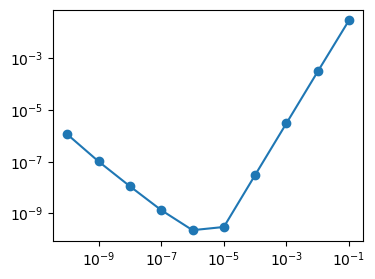

In [35]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, 'o-')
i1 = 13
i2 = 10
#plt.plot(eps_arr[-i1:], eps_arr[-i1:]**(-1) / 10**15, '--')
#plt.plot(eps_arr[:i2], eps_arr[:i2]**2 * 10**2, '--')
plt.xscale("log")
plt.yscale("log")

#### debug

In [82]:
diff_tens = np.zeros(eps_arr.shape + CB_lammps.shape)
for k, eps in enumerate(eps_arr):
    CB = compute_born_stress_der2(lmp, cell_matrix_ref=cell_matrix, eps=eps, undeform=True)
    diff_tens[k] = CB_lammps - CB

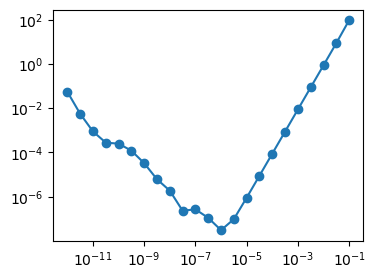

In [85]:
debug_ind = (0,0,0,0)
plt.figure(figsize=(4,3))
plt.plot(eps_arr, np.abs(diff_tens[:,*debug_ind]), 'o-')
plt.xscale("log")
plt.yscale("log")

In [292]:
sigma_lammps

array([[-32.17135707,   0.07407182,  -0.33290626],
       [  0.07407182, -31.95978856,  -0.64820662],
       [ -0.33290626,  -0.64820662, -30.22176151]])

In [336]:
CB_lammps[*debug_ind]

np.float64(139.9701074755643)

In [337]:
CB_lammps[*debug_ind] + sigma_lammps[*debug_ind[-2:]]

np.float64(140.04417929579247)

In [338]:
CB[*debug_ind]

np.float64(140.07578053898897)

In [342]:
sigma_lammps[0,1] + sigma_lammps[0,2]

np.float64(-0.25883444063466915)

In [343]:
sigma_lammps[0,1] + sigma_lammps[1,2]

np.float64(-0.5741347970034069)

In [344]:
sigma_lammps[0,2] + sigma_lammps[1,2]

np.float64(-0.9811128780944222)

In [403]:
for i in range(3):
    for j in range(3):
        for k in range(3):
            for l in range(3):
                if np.abs(CB[i,j,k,l] - CB_lammps[i,j,k,l]) > 1e-3:
                    print(i,j,k,l, np.abs(CB[i,j,k,l] - 2*sym_dyad(I, sigma_lammps)[i,j,k,l] - CB_lammps[i,j,k,l]) / np.abs(CB_lammps[i,j,k,l]))

1 0 0 0 2.6075741642842913e-05
1 0 0 1 0.000755770904487847
1 0 0 2 0.26109123058287
1 0 1 0 0.000755770904487847
1 0 1 1 3.642402683414567e-05
1 0 1 2 0.0614075752537003
1 0 2 0 0.26109123058287
1 0 2 1 0.0614075752537003
2 0 0 0 1.7587993752545388e-05
2 0 0 1 0.26112947522960817
2 0 0 2 0.007277695947041442
2 0 1 0 0.26112947522960817
2 0 2 0 0.007277695947041442
2 0 2 2 2.467914393694279e-06
2 1 1 1 1.2002940512716032e-05
2 1 1 2 0.006399153884534345
2 1 2 1 0.006399153884534345
2 1 2 2 2.6139198260251622e-05


### at finite strain

In [32]:
deform0 = np.triu(np.random.rand(3,3)) / 4
deform0

array([[0.17038719, 0.20279702, 0.06940389],
       [0.        , 0.12954239, 0.01339975],
       [0.        , 0.        , 0.07871513]])

In [33]:
I = np.eye(3)
F0 = I + deform0

In [34]:
cell_matrix_def = F0 @ cell_matrix
lmp.command("change_box all triclinic")
set_cell_matrix(lmp, cell_matrix_def, remap=True)

In [35]:
born_vector = lmp.numpy.extract_compute("born_matrix", 0, 1) / lmp.extract_variable("vol")
CB_lammps_def = voigt_to_tensor(lammps_array_to_matrix(born_vector))

In [36]:
eps_arr = np.logspace(-3, -10, 15)
diff_arr = np.zeros_like(eps_arr)
for k, eps in enumerate(eps_arr):
    CB = compute_born_stress_der(lmp, cell_matrix_ref=cell_matrix_def, eps=eps, undeform=False)
    diff_arr[k] = np.linalg.norm(CB_lammps_def - CB) / np.linalg.norm(CB_lammps_def)

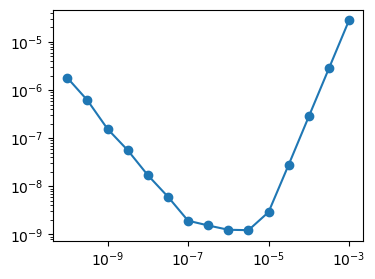

In [37]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, 'o-')
plt.xscale("log")
plt.yscale("log")

In [38]:
eps_arr = np.logspace(-2, -10, 17)
diff_arr = np.zeros_like(eps_arr)
for k, eps in enumerate(eps_arr):
    CB = compute_born_stress_der2(lmp, cell_matrix_ref=F0@cell_matrix, eps=eps, undeform=False)
    diff_arr[k] = np.linalg.norm(CB_lammps_def - CB) / np.linalg.norm(CB_lammps_def)

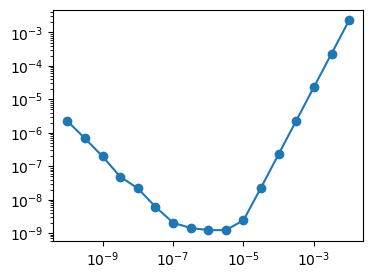

In [39]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, 'o-')
plt.xscale("log")
plt.yscale("log")

## as potential second derivative

### via the 2nd Piola-Kirchhoff computed as potential derivative

In [36]:
def get_pot_en_deformed(lmp, cell_matrix_deformed):
    set_cell_matrix(lmp, cell_matrix_deformed, remap=True)
    return lmp.get_thermo("pe")

def compute_cauchy_pot(lmp, cell_matrix, eps=1e-7):
    deforms, map_ij = probe_deformations(eps)
    I = np.eye(3)
    rho = lmp.get_natoms() / np.linalg.det(cell_matrix)
    sigma = np.zeros((3,3))
    for (i,j), deform in zip(map_ij, deforms):
        U1 = get_pot_en_deformed(lmp, (I - deform)@cell_matrix)
        U2 = get_pot_en_deformed(lmp, (I + deform)@cell_matrix)     
        sigma[i,j] = (U2 - U1) * rho / 2 / eps
    sigma[np.tril_indices_from(sigma, k=-1)] = sigma[np.triu_indices_from(sigma, k=1)]
    return sigma

def compute_pk2_pot(lmp, cell_matrix_ref, F, eps=1e-7):
    F_inv = np.linalg.inv(F)
    sigma = compute_cauchy_pot(lmp, F@cell_matrix_ref, eps)
    return np.linalg.det(F) * F_inv @ sigma @ F_inv.T

In [37]:
def compute_born_pot_der(lmp, cell_matrix=None, eps=1e-7):
    deforms, map_ij = probe_deformations(eps)
    
    lmp.command("change_box all triclinic")
    h0 = get_cell_matrix(lmp) if cell_matrix is None else cell_matrix
    CB = np.zeros((3,)*4)
    
    for (k,l), deform in zip(map_ij, deforms):
        S1 = compute_pk2_pot(lmp, h0, np.eye(3)-deform, eps)
        S2 = compute_pk2_pot(lmp, h0, np.eye(3)+deform, eps)
        CB[..., k, l] = (S2 - S1)/(2*eps)
        if k != l:
            CB[..., l, k] = (S2 - S1)/(2*eps)

    set_cell_matrix(lmp, h0, remap=True)

    return CB

In [38]:
set_cell_matrix(lmp, cell_matrix, remap=True)
cell_is_undeformed(lmp)

np.True_

In [39]:
eps_arr = np.logspace(-1, -10, 19)
diff_arr = np.zeros_like(eps_arr)
lmp.command("change_box all triclinic")

for k, eps in enumerate(eps_arr):
    CB = compute_born_pot_der(lmp, cell_matrix, eps)
    diff_arr[k] = np.linalg.norm(CB_lammps - CB) / np.linalg.norm(CB_lammps)

cell_is_undeformed(lmp)

np.True_

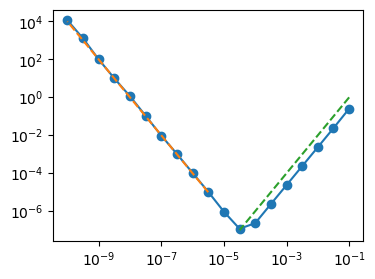

In [40]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, "o-")
i1 = 10
i2 = 8
plt.plot(eps_arr[-i1:], eps_arr[-i1:]**(-2) / 10**16, '--')
plt.plot(eps_arr[:i2], eps_arr[:i2]**2 * 10**2, '--')
plt.xscale("log")
plt.yscale("log")

In [77]:
CB = compute_born_pot_der(lmp, eps=1e-7)
major_symmetry(CB)

np.float64(2.2466517747019257)

In [78]:
major_symmetry(CB, (1,2,0,0))

np.float64(-0.3406386445137244)

### via the 2nd order derivative explicitly

In [79]:
lmp.command("change_box all triclinic")

In [41]:
set_cell_matrix(lmp, cell_matrix, remap=True)
cell_is_undeformed(lmp)

np.True_

In [42]:
def get_pot_en_deformed(lmp, cell_matrix_deformed):
    set_cell_matrix(lmp, cell_matrix_deformed, remap=True, convert=True)
    return lmp.get_thermo("pe")
    #return lmp.extract_compute('thermo_pe', 0, 0)

def compute_cauchy_pot(lmp, cell_matrix, eps=1e-7):
    deforms, map_ij = probe_deformations(eps)
    I = np.eye(3)
    rho = lmp.get_natoms() / np.linalg.det(cell_matrix)
    sigma = np.zeros((3,3))
    for (i,j), deform in zip(map_ij, deforms):
        U1 = get_pot_en_deformed(lmp, (I - deform)@cell_matrix)
        U2 = get_pot_en_deformed(lmp, (I + deform)@cell_matrix)
        sigma[i,j] = (U2 - U1) * rho / 2 / eps
    sigma[np.tril_indices_from(sigma, k=-1)] = sigma[np.triu_indices_from(sigma, k=1)]
    return sigma

def compute_born_pot_der_explicit(lmp, cell_matrix=None, eps=1e-7, undeform=True):
    deforms, map_ij = probe_deformations(eps)
    lmp.command("change_box all triclinic")
    h0 = get_cell_matrix(lmp) if cell_matrix is None else cell_matrix
    CB = np.zeros((3,)*4)
    I = np.eye(3)
    sigma = compute_cauchy_pot(lmp, h0, eps)
    rho = lmp.get_thermo('density')
    
    for (i,j), deform1 in zip(map_ij, deforms):
        for (k,l), deform2 in zip(map_ij, deforms):
            U11 = get_pot_en_deformed(lmp, (I - deform1)@(I - deform2)@h0)
            U12 = get_pot_en_deformed(lmp, (I - deform1)@(I + deform2)@h0)
            U21 = get_pot_en_deformed(lmp, (I + deform1)@(I - deform2)@h0)
            U22 = get_pot_en_deformed(lmp, (I + deform1)@(I + deform2)@h0)
            CB[i,j,k,l] = ((U22 + U11 - U12 - U21) * rho / (4 * eps**2)
                           - (i==k)*sigma[j,l] - (j==k) * sigma[i,l])
            if k != l:
                CB[i, j, l, k] = CB[i, j, k, l]
        if i != j:
            CB[j, i] = CB[i, j]
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)

    return CB

In [71]:
# does not work
def compute_born_pot_der_explicit2(lmp, cell_matrix=None, eps=1e-7, undeform=True):
    deforms, map_ij = probe_deformations(eps)
    lmp.command("change_box all triclinic")
    h0 = get_cell_matrix(lmp) if cell_matrix is None else cell_matrix
    V0 = np.linalg.det(h0)
    CB = np.zeros((3,)*4)
    I = np.eye(3)
    sigma = compute_cauchy_pot(lmp, h0, eps)
    rho = lmp.get_thermo('density')
    P = np.zeros((3,3))
    
    for i in range(3):
        for j in range(3):
            deform1 = np.zeros((3,3))
            deform1[i,j] = eps
            P[i,j] = (get_pot_en_deformed(lmp, (I + deform1)@h0) 
                      - get_pot_en_deformed(lmp, (I - deform1)@h0)) * rho / 2 / eps
            for k in range(3):
                for l in range(3):
                    deform2 = np.zeros((3,3))
                    deform2[k,l] = eps
                    U11 = get_pot_en_deformed(lmp, (I - deform1 - deform2)@h0)
                    U12 = get_pot_en_deformed(lmp, (I - deform1 + deform2)@h0)
                    U21 = get_pot_en_deformed(lmp, (I + deform1 - deform2)@h0)
                    U22 = get_pot_en_deformed(lmp, (I + deform1 + deform2)@h0)
                    CB[i,j,k,l] = (U22 + U11 - U12 - U21) * rho / (4 * eps**2)
    CB -= sym_dyad(np.eye(3), P)
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)
        lmp.command("run 0")

    return CB

In [43]:
def compute_F_deform(E):
    return np.linalg.cholesky(I + 2*E, upper=True)

def compute_born_pot_der_explicit3(lmp, cell_matrix=None, eps=1e-7, undeform=True):
    E_deforms, map_ij = probe_deformations_sym(eps)
    
    h0 = get_cell_matrix(lmp) if cell_matrix is None else cell_matrix
    CB = np.zeros((3,)*4)
    rho = lmp.get_thermo('density')
    
    for (i,j), dE1 in zip(map_ij, E_deforms):
        for (k,l), dE2 in zip(map_ij, E_deforms):
            U11 = get_pot_en_deformed(lmp, compute_F_deform(- dE1 - dE2) @ h0)
            U12 = get_pot_en_deformed(lmp, compute_F_deform(- dE1 + dE2) @ h0)
            U21 = get_pot_en_deformed(lmp, compute_F_deform(+ dE1 - dE2) @ h0)
            U22 = get_pot_en_deformed(lmp, compute_F_deform(+ dE1 + dE2) @ h0)
            CB[i,j,k,l] = (U22 + U11 - U12 - U21) * rho / (4 * eps**2)
            if k != l:
                CB[i, j, l, k] = CB[i, j, k, l]
        if i != j:
            CB[j, i] = CB[i, j]
    
    if undeform:
        set_cell_matrix(lmp, h0, remap=True)

    return CB

In [44]:
eps_arr = np.logspace(-1, -9, 19)
diff_arr = np.zeros_like(eps_arr)
lmp.command("change_box all triclinic")

for k, eps in enumerate(eps_arr):
    CB = compute_born_pot_der_explicit3(lmp, cell_matrix, eps)
    diff_arr[k] = np.linalg.norm(CB_lammps - CB) / np.linalg.norm(CB_lammps)

cell_is_undeformed(lmp)

np.True_

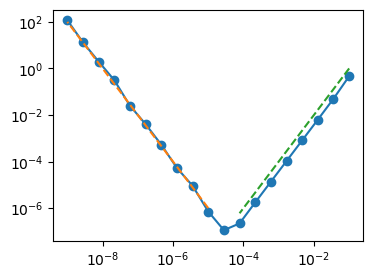

In [45]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, "o-")
i1 = 10
i2 = 8
plt.plot(eps_arr[-i1:], eps_arr[-i1:]**(-2) / 10**16, '--')
plt.plot(eps_arr[:i2], eps_arr[:i2]**2 * 10**2, '--')
plt.xscale("log")
plt.yscale("log")

#### debug

In [59]:
eps_arr = np.logspace(-3, -8, 11)
diff_tens = np.zeros(eps_arr.shape + CB_lammps.shape)
for k, eps in enumerate(eps_arr):
    CB = compute_born_pot_der_explicit2(lmp, cell_matrix, eps)
    diff_tens[k] = CB_lammps - CB

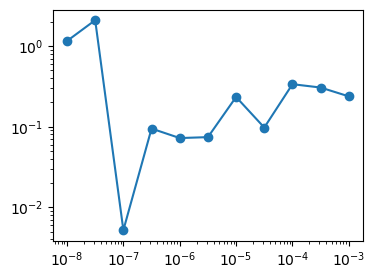

In [486]:
debug_ind = (0,0,0,1)
plt.figure(figsize=(4,3))
plt.plot(eps_arr, np.abs(diff_tens[:,*debug_ind]), 'o-')
plt.xscale("log")
plt.yscale("log")

In [487]:
sigma_lammps

array([[-32.17135707,   0.07407182,  -0.33290626],
       [  0.07407182, -31.95978856,  -0.64820662],
       [ -0.33290626,  -0.64820662, -30.22176151]])

In [488]:
CB_lammps[*debug_ind]

np.float64(1.0447721128285503)

In [491]:
CB_lammps[*debug_ind] - sigma_lammps[1,2] - sigma_lammps

np.float64(2.3411853472917104)

In [490]:
CB[*debug_ind]

np.float64(2.2010879221934236)

In [342]:
sigma_lammps[0,1] + sigma_lammps[0,2]

np.float64(-0.25883444063466915)

In [343]:
sigma_lammps[0,1] + sigma_lammps[1,2]

np.float64(-0.5741347970034069)

In [344]:
sigma_lammps[0,2] + sigma_lammps[1,2]

np.float64(-0.9811128780944222)

In [403]:
for i in range(3):
    for j in range(3):
        for k in range(3):
            for l in range(3):
                if np.abs(CB[i,j,k,l] - CB_lammps[i,j,k,l]) > 1e-3:
                    print(i,j,k,l, np.abs(CB[i,j,k,l] - 2*sym_dyad(I, sigma_lammps)[i,j,k,l] - CB_lammps[i,j,k,l]) / np.abs(CB_lammps[i,j,k,l]))

1 0 0 0 2.6075741642842913e-05
1 0 0 1 0.000755770904487847
1 0 0 2 0.26109123058287
1 0 1 0 0.000755770904487847
1 0 1 1 3.642402683414567e-05
1 0 1 2 0.0614075752537003
1 0 2 0 0.26109123058287
1 0 2 1 0.0614075752537003
2 0 0 0 1.7587993752545388e-05
2 0 0 1 0.26112947522960817
2 0 0 2 0.007277695947041442
2 0 1 0 0.26112947522960817
2 0 2 0 0.007277695947041442
2 0 2 2 2.467914393694279e-06
2 1 1 1 1.2002940512716032e-05
2 1 1 2 0.006399153884534345
2 1 2 1 0.006399153884534345
2 1 2 2 2.6139198260251622e-05


In [343]:
debug_ind = (0,2,1,1)
CB = compute_born_pot_der_explicit(lmp, 1e-7, debug=True)
major_symmetry(CB, norm_ord=np.inf)

1 1 0 2
-12254.632308586119 -12254.632308586295
0 2 1 1
-12254.632308585306 -12254.632308585446
0.0


np.float64(0.3608420229284093)

In [345]:
(-12254.632308586119 + 12254.632308586295) / (4 * 1e-14 * np.linalg.det(cell_matrix))

np.float64(1.166722540801857)

In [356]:
1e-14 * np.linalg.det(cell_matrix)

np.float64(3.7807183364839304e-11)

In [346]:
(-12254.632308585306 + 12254.632308585446) / (4 * 1e-14 * np.linalg.det(cell_matrix))

np.float64(0.9261611921829175)

In [344]:
major_symmetry(CB, (0,2,1,1))

np.float64(-0.23454731490346614)

# Stress as poterntial derivative at finite strain

In [46]:
deform0 = np.triu(np.random.rand(3,3)) / 4
deform0

array([[0.20119456, 0.21073901, 0.15676882],
       [0.        , 0.03941932, 0.11346706],
       [0.        , 0.        , 0.17870444]])

In [47]:
I = np.eye(3)
F0 = I + deform0

In [48]:
cell_matrix_def = F0 @ cell_matrix
lmp.command("change_box all triclinic")
set_cell_matrix(lmp, cell_matrix_def, remap=True)

def calc_stress(lmp, F):
    sigma = -lammps_array_to_matrix(lmp.numpy.extract_compute("press_pot", 0, 1))
    F_inv = np.linalg.inv(F)
    P = np.linalg.det(F) * sigma @ F_inv.T
    S = F_inv @ P
    return sigma, S, P

sigma_ref, S_ref, P_ref = calc_stress(lmp, F0)

In [49]:
S_ref

array([[ 2.65937992,  1.8599583 , -0.38064889],
       [ 1.8599583 ,  2.81722477,  0.56882006],
       [-0.38064889,  0.56882006,  4.2572889 ]])

In [50]:
sigma_ref

array([[3.33143596, 2.08571999, 0.26434723],
       [2.08571999, 2.19662257, 0.86044536],
       [0.26434723, 0.86044536, 4.01914711]])

In [51]:
P_ref

array([[ 3.52672459,  2.9170442 ,  0.33004937],
       [ 1.89008548,  2.99282019,  1.0743046 ],
       [-0.44867254,  0.67047073,  5.01808535]])

In [52]:
def get_vel(lmp):
    return np.ctypeslib.as_array(lmp.gather_atoms("v", 1, 3)).reshape(-1, 3)

# does not work for some reason
def set_vel(lmp, v):
    data = v.flatten()  # the data should be stored until lmp.scatter_atoms is finished
    #return lmp.scatter_atoms("v", 1, 3, data.ctypes.data)
    return lmp.scatter_atoms("v", 1, 3, np.ctypeslib.as_ctypes(data))
    #return lmp.scatter_atoms("v", 1, 3, lmp.gather_atoms('v', 1, 3))

## Cauchy and 2nd Piola-Kirchhoff (symmetric)

In [53]:
def get_pot_en_deformed(lmp, cell_matrix_deformed):
    set_cell_matrix(lmp, cell_matrix_deformed, remap=True)
    return lmp.get_thermo("pe")

def compute_cauchy_pot(lmp, cell_matrix, eps=1e-7):
    deforms, map_ij = probe_deformations(eps)
    I = np.eye(3)
    rho = lmp.get_natoms() / np.linalg.det(cell_matrix)
    sigma = np.zeros((3,3))
    for (i,j), deform in zip(map_ij, deforms):
        U1 = get_pot_en_deformed(lmp, (I - deform)@cell_matrix)
        U2 = get_pot_en_deformed(lmp, (I + deform)@cell_matrix)     
        sigma[i,j] = (U2 - U1) * rho / 2 / eps
    sigma[np.tril_indices_from(sigma, k=-1)] = sigma[np.triu_indices_from(sigma, k=1)]
    return sigma

In [54]:
sigma = compute_cauchy_pot(lmp, F0@cell_matrix)
sigma

array([[3.33143597, 2.08572   , 0.26434728],
       [2.08572   , 2.19662257, 0.86044532],
       [0.26434728, 0.86044532, 4.0191471 ]])

In [55]:
sigma - sigma_ref

array([[ 7.90994514e-09,  5.17461718e-09,  5.06824292e-08],
       [ 5.17461718e-09, -4.86968244e-10, -3.27259611e-08],
       [ 5.06824292e-08, -3.27259611e-08, -1.14078267e-08]])

In [56]:
eps_arr = np.logspace(-3, -10, 15)
diff_arr = np.zeros_like(eps_arr)
for k, eps in enumerate(eps_arr):
    sigma = compute_cauchy_pot(lmp, F0@cell_matrix, eps)
    diff_arr[k] = np.linalg.norm(sigma - sigma_ref) / np.linalg.norm(sigma_ref)

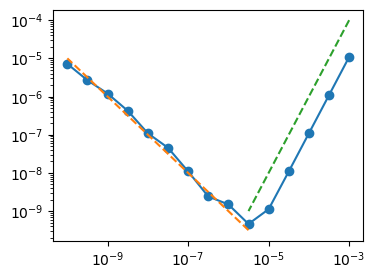

In [57]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, 'o-')
i1 = 10
i2 = 6
plt.plot(eps_arr[-i1:], eps_arr[-i1:]**(-1) / 10**15, '--')
plt.plot(eps_arr[:i2], eps_arr[:i2]**2 * 10**2, '--')
plt.xscale("log")
plt.yscale("log")

In [58]:
def compute_pk2_pot(lmp, cell_matrix_ref, F, eps=1e-7):
    F_inv = np.linalg.inv(F)
    sigma = compute_cauchy_pot(lmp, F@cell_matrix_ref, eps)
    return np.linalg.det(F) * F_inv @ sigma @ F_inv.T

In [59]:
S = compute_pk2_pot(lmp, cell_matrix, F0)
S

array([[ 2.65937989,  1.85995832, -0.38064887],
       [ 1.85995832,  2.81722478,  0.56882002],
       [-0.38064887,  0.56882002,  4.25728891]])

In [60]:
S - S_ref

array([[-2.69485230e-08,  1.52998016e-08,  1.88414014e-08],
       [ 1.52998016e-08,  1.23658404e-08, -4.02061489e-08],
       [ 1.88414015e-08, -4.02061491e-08,  8.20695156e-09]])

## 1st Piola-Kirchhoff (nonsymmetric)

In [61]:
def get_pot_en_deformed(lmp, cell_matrix_deformed, convert=False):
    set_cell_matrix(lmp, cell_matrix_deformed, remap=True, convert=convert)
    return lmp.get_thermo("pe")

In [62]:
def compute_pk1_pot(lmp, F, cell_matrix, eps=1e-7):
    deforms, map_ij = probe_deformations(eps)
    V0 = np.linalg.det(cell_matrix)
    P = np.zeros((3,3))
    
    for (i,j), deform in zip(map_ij, deforms):       
        U1 = get_pot_en_deformed(lmp, (F - deform)@cell_matrix)
        U2 = get_pot_en_deformed(lmp, (F + deform)@cell_matrix)
        P[i,j] = (U2 - U1) * lmp.get_natoms() / 2 / eps / V0
        
        if i != j:
            U1 = get_pot_en_deformed(lmp, (F - deform.T)@cell_matrix, convert=True)
            U2 = get_pot_en_deformed(lmp, (F + deform.T)@cell_matrix, convert=True)
            P[j,i] = (U2 - U1) * lmp.get_natoms() / 2 / eps / V0

    return P

In [63]:
P = compute_pk1_pot(lmp, F0, cell_matrix)
P

array([[ 3.52672455,  2.91704428,  0.33004932],
       [ 1.89008543,  2.99282018,  1.07430456],
       [-0.44867251,  0.67047077,  5.01808544]])

In [64]:
P - P_ref

array([[-3.76683453e-08,  7.32420649e-08, -4.62492177e-08],
       [-5.50753161e-08, -6.42388454e-09, -4.19695803e-08],
       [ 3.27798337e-08,  3.65452270e-08,  8.48208730e-08]])

In [65]:
eps_arr = np.logspace(-1, -10, 19)
diff_arr = np.zeros_like(eps_arr)
for k, eps in enumerate(eps_arr):
    P = compute_pk1_pot(lmp, F0, cell_matrix, eps)
    diff_arr[k] = np.linalg.norm(P - P_ref) / np.linalg.norm(P_ref)

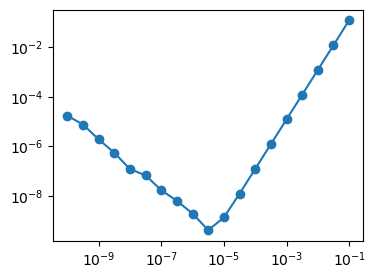

In [66]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, 'o-')
i1 = 10
i2 = 6
#plt.plot(eps_arr[-i1:], eps_arr[-i1:]**(-1) / 10**15, '--')
#plt.plot(eps_arr[:i2], eps_arr[:i2]**2 * 10**2, '--')
plt.xscale("log")
plt.yscale("log")

## Cauchy as symmetric derivative

In [67]:
def compute_cauchy_pot2(lmp, cell_matrix, eps=1e-7):
    deforms, map_ij = probe_deformations_sym(eps)
    V0 = np.linalg.det(cell_matrix)
    sigma = np.zeros((3,3))
    
    for (i,j), deform in zip(map_ij, deforms):       
        U1 = get_pot_en_deformed(lmp, (I - deform)@cell_matrix, convert=True)
        U2 = get_pot_en_deformed(lmp, (I + deform)@cell_matrix, convert=True)
        sigma[i,j] = (U2 - U1) * lmp.get_natoms() / 2 / eps / V0
        if i != j:
            sigma[j,i] = sigma[i,j]

    return sigma

In [68]:
sigma2 = compute_cauchy_pot2(lmp, F0@cell_matrix)
sigma2 - sigma_ref

array([[ 1.11025620e-08, -1.21061694e-09,  1.87562588e-08],
       [-1.21061694e-09,  9.09088271e-09, -4.23038122e-08],
       [ 1.87562588e-08, -4.23038122e-08, -8.21520985e-09]])

In [69]:
eps_arr = np.logspace(-1, -10, 19)
diff_arr = np.zeros_like(eps_arr)
for k, eps in enumerate(eps_arr):
    sigma2 = compute_cauchy_pot2(lmp, F0@cell_matrix, eps=eps)
    diff_arr[k] = np.linalg.norm(sigma2 - sigma_ref) / np.linalg.norm(sigma_ref)

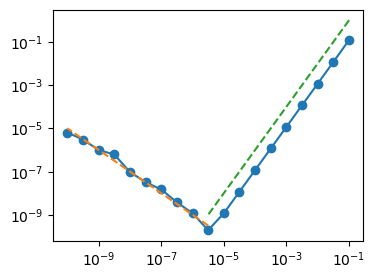

In [70]:
plt.figure(figsize=(4,3))
plt.plot(eps_arr, diff_arr, 'o-')
i1 = 10
i2 = 10
plt.plot(eps_arr[-i1:], eps_arr[-i1:]**(-1) / 10**15, '--')
plt.plot(eps_arr[:i2], eps_arr[:i2]**2 * 10**2, '--')
plt.xscale("log")
plt.yscale("log")